# Joint distributions exercise

You are given a three-dimensional dataset with variables:

- 'Wsp' is the 10-minute average wind speed;
- 'SigmaU' is the standard deviation of the 10-minute average wind speed;
- 'Rho' is the air density

The wind speed and turbulence are conditionally dependent on each other, while the air density can be considered independent from the other two variables. 

Your task is to:

1) Load the dataset 'Multivariate_dist_exercise_data.csv' into pandas
2) Try to plot the variables and illustrate their dependencies
3) Fit a marginal Weibull distribution to the wind speed 
4) Fit a conditional LogNormal distribution to the turbulence, considering a linear or quadratic dependence of the mean turbulence to the wind speed;
5) Fit a Normal distribution to the air density: does it have to be conditional or not?
6) Try to generate a random sample of the three varaibles and compare to the original data set

In [5]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import scipy
import matplotlib.pyplot as plt
import sklearn
import sklearn.neural_network

In [19]:
# LOADING THE DATASET
WindData = pd.read_csv('Multivariate_dist_exercise_data.csv')
WindData

,Wsp,SigmaU,Rho
0,9.9196,0.179545,1.284383
1,9.5073,0.137856,1.211200
2,9.5274,0.200075,1.212646
3,9.9498,0.251730,1.258337
4,10.2376,0.154588,1.191076
...,...,...,...
429724,15.6264,1.207921,1.195205
429725,13.7150,0.789984,1.232585
429726,13.4969,1.075703,1.241341
429727,13.4135,1.386956,1.238772


Now, let us take a look at the data. A pairplot is a useful way to get an overview of the distributions and relationships between several variables.

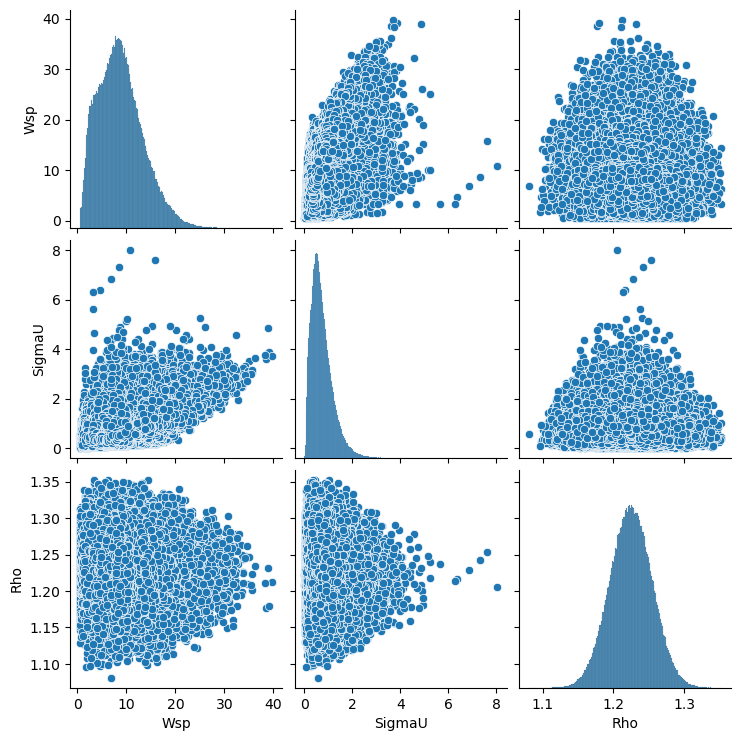

In [20]:
import seaborn as sns
sns.pairplot(WindData)

In [23]:
np.corrcoef([WindData["Wsp"],WindData["SigmaU"],WindData["Rho"]])

array([[ 1.        ,  0.49462218, -0.00182087],
       [ 0.49462218,  1.        , -0.00136182],
       [-0.00182087, -0.00136182,  1.        ]])

Below, we have a few helper functions - mainly in order to be able to make computations with the lognormal distribution by specifying the mean and standard deviation of the data directly. The standard parameter inputs for the lognormal distribution are quite confusing and using them often lead to errors. One can use the functions below, or make sure the output from the standard Python functions is equivalent.

In [24]:
# Helper function - Normal distribution
def NormalDist(task,x,mu=0,sigma=1):
    import numpy as np
    if task == 0: # PDF
        y = (1.0/(sigma*np.sqrt(2.0*np.pi)))*np.exp(-((x - mu)**2)/(2.0*(sigma**2)))
    elif task == 1: # Cumulative
        from scipy.special import erf
        y = 0.5*(1.0 + erf((x - mu)/(sigma*np.sqrt(2))))
    elif task == 2: # Inverse
        from scipy.special import erfinv
        y = mu + sigma*np.sqrt(2)*erfinv(2*x - 1)        
    return y

# Helper function - lognormal distribution
def LogNormDist(task,x,mu,sigma):
    import numpy as np
    tol = 1e-16
    mu = np.asarray(mu)
    mu[mu<tol] = tol
    Eps   = np.sqrt(np.log( 1.0+(sigma/mu)**2 ) )
    Ksi   = np.log(mu)-0.5*Eps**2
    if task == 0: # PDF
        x[x<=0] = 1e-8
        u =(np.log(x)-Ksi)/Eps
        y = np.exp(-u*u/2.0)/(Eps*x*np.sqrt(2.0*np.pi))
    elif task == 1: # Cummulative
        x[x<=0] = 1e-8
        u =(np.log(x)-Ksi)/Eps
        y= NormalDist(1, u)
    elif task == 2: # Inverse
        y= np.exp(Ksi+Eps*NormalDist(2, x))
    
    return y

We choose to consider the wind speed first - as the variable driving most other variables, it can be considered independently. Note that if we want to model a joint distribution of multiple variables in terms of a cascade of conditional approximations, at least one variable needs to be considered as independent from all other. The cell below fits a marginal distribution for the average wind speed.

In [25]:
# WIND SPEED DISTRIBUTION FIT
Wsp0 = np.asarray(WindData['Wsp'])
WeibLikelihoodFunc = lambda theta: -np.sum(np.log(stats.weibull_min.pdf(Wsp0, loc = 0, scale = theta[0], c = theta[1])))
theta0 = [8,1.5]
Weib0 = scipy.optimize.minimize(WeibLikelihoodFunc, theta0)
WeibullA = Weib0.x[0]
Weibullk = Weib0.x[1]

In [30]:
WeibullA

np.float64(9.98373851187839)

Now, we need to consider our second variable - the turbulence. As seen from the pair plot, there is dependence between wind speed and turbulence at least - meaning that we need to describe this relationship in order to define a joint distribution of $(u, \sigma_u)$. With conditional dependences, we make the distribution parameters of the dependent variable a function of the value(s) of the conditioning variables. Below, we'll build this relationship by binning the wind speed measurements, and fitting a **different** probability distribution of turbulence in **every** wind speed bin. 

After fitting the turbulence distributions to each wind speed bin, we may either directly use the results, or we may go one step further and fit a continuous relationship between the wind speed and the turbulence distribution parameters. With a continuous relationship, we can directly estimate conditional probabilities for arbitrary data points, and we can generate random samples of jointly distributed variables. 

The type of conditional relationship built in this way may be called a "sequential copula", where "copula" by definition is any function which computes the joint distribution of variables from the marginal cdf of each variable.

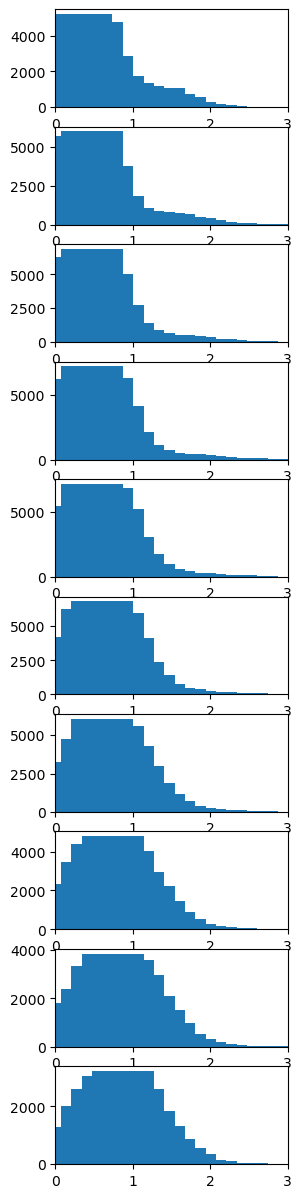

In [47]:
# CONDITIONAL DISTRIBUTION OF TURBULENCE - BASED ON DATA BINNING
WspBinEdges = np.arange(3.5,33.5,1)
WspBinCenters = WspBinEdges[:-1] + 0.5

MuSigmaBinned = np.zeros(len(WspBinCenters))
SigmaSigmaBinned = np.zeros(len(WspBinCenters))

nData = len(WindData['Wsp'])

fig0,ax0 = plt.subplots(10,1,figsize = (3,15))
sigmaU_hist = np.histogram(WindData["SigmaU"],60)
histogram_ticks = sigmaU_hist[1][1:] - 0.5*(sigmaU_hist[1][1] - sigmaU_hist[1][0])
# Per wind speed
for iWsp in range(len(WspBinCenters)):
    WspBinSelection = (WindData['Wsp'] > WspBinEdges[iWsp]) & (WindData['Wsp'] <= WspBinEdges[iWsp + 1])
    MuSigmaBinned[iWsp] = np.mean(WindData.loc[WspBinSelection,'SigmaU'])
    SigmaSigmaBinned[iWsp] = np.std(WindData.loc[WspBinSelection,'SigmaU'])
    hist_i = np.histogram(WindData.loc[WspBinSelection,'SigmaU'], bins = sigmaU_hist[1])
    if iWsp < 10:
        ax0[iWsp].bar(histogram_ticks,hist_i[0])
        ax0[iWsp].set_xlim([0,3])
    
Mudatax = WspBinCenters[~np.isnan(MuSigmaBinned)]
Mudatay = MuSigmaBinned[~np.isnan(MuSigmaBinned)]
SigmaDatay = SigmaSigmaBinned[~np.isnan(SigmaSigmaBinned)]

# Use polyfit (for example np.polyfit). Which order works well - 0, 1, or 2?
pMu = np.polyfit(Mudatax,Mudatay,deg = 2)
SigmaSigmaRef = np.mean(SigmaSigmaBinned)
        
MuSigmaFunc = lambda u: pMu[0]*u**2 + pMu[1]*u + pMu[2]
SigmaSigmaFunc = lambda u: SigmaSigmaRef


In [40]:
histogram_ticks.shape

(30,)

In [ ]:
pMu

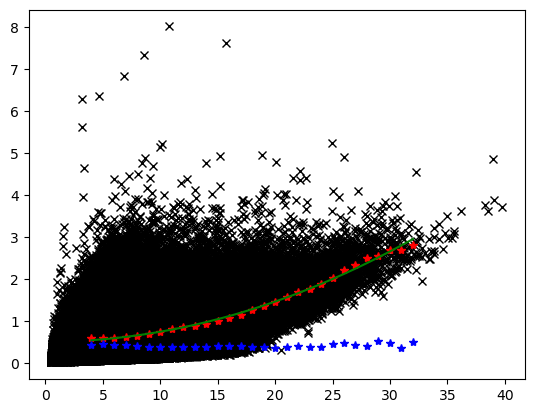

In [46]:
# PLOT THE FITTING RESULTS AND THE CONTIUOUS PARAMETER FITS
import matplotlib.pyplot as plt

plt.plot(WindData['Wsp'],WindData['SigmaU'],'xk')
plt.plot(Mudatax, Mudatay, '*r')
plt.plot(Mudatax, SigmaDatay,'*b')
plt.plot(Mudatax, MuSigmaFunc(Mudatax),'-g')

As mentioned earlier, the fitted conditional probability distribution can be used to generate random samples of the jointly distributed variables. We should be therefore be able to reproduce the $(u,\sigma_u)$ distribution from data. This is done in the cells below.

In [90]:

N = len(WindData)
#Urand = stats.weibull_min.ppf(np.random.rand(N), loc = 0, scale = WeibullA, c = Weibullk)
Urand = stats.weibull_min.rvs(c = Weibullk, scale = WeibullA, loc = 0, size = N)
MuSigmaUrand = MuSigmaFunc(Urand)
SigmaSigmaUrand = SigmaSigmaFunc(Urand)
SigmaUrand = LogNormDist(2,np.random.rand(N),MuSigmaUrand,SigmaSigmaUrand)
MuAlpha = 0.1
SigmaAlpha = np.min(np.array([np.ones(len(Urand)), 1/Urand]), axis = 0)
Alpha_rand = stats.norm.ppf(np.random.rand(N), loc = MuAlpha, scale = SigmaAlpha)

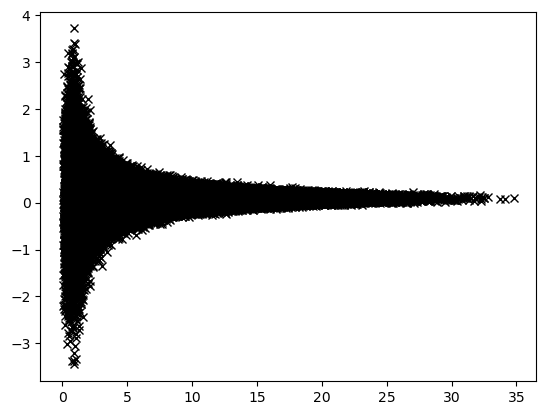

In [91]:
plt.plot(Urand, Alpha_rand, 'xk')

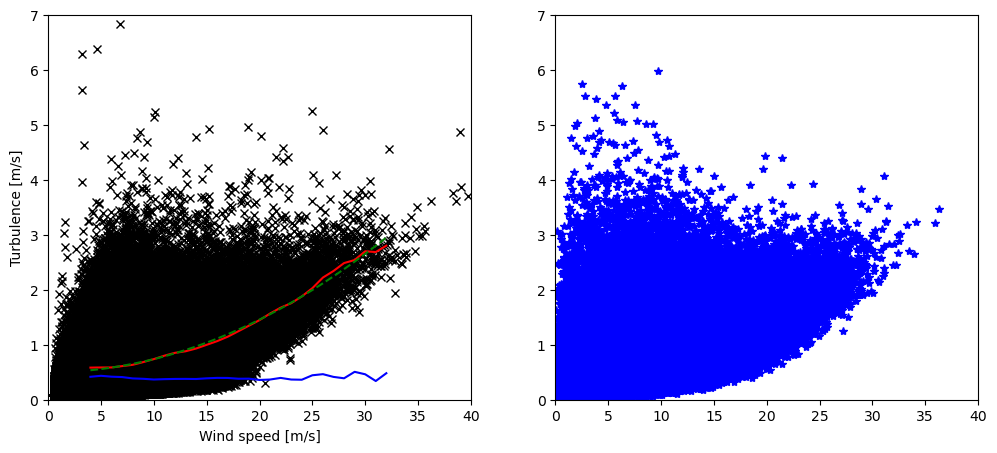

In [49]:
# PLOT TURBULENCE INCLUDING DISTRIBUTION PARAMETERS

# ROSENBLATT TRANSFORMATION (SEQUENTIAL COPULA)

fig,ax = plt.subplots(1,2, figsize = (12,5))
ax[0].plot(WindData['Wsp'],WindData['SigmaU'],'xk')
ax[0].plot(WspBinCenters,MuSigmaBinned,'-r')
ax[0].plot(WspBinCenters,SigmaSigmaBinned,'-b')
ax[0].plot(WspBinCenters,MuSigmaFunc(WspBinCenters),'--g')
ax[0].set_xlim([0,40])
ax[0].set_ylim([0,7])
ax[0].set_xlabel('Wind speed [m/s]')
ax[0].set_ylabel('Turbulence [m/s]')
ax[1].plot(Urand,SigmaUrand,'*b')
ax[1].set_xlim([0,40])
ax[1].set_ylim([0,7])
plt.show()

We have one more variable in the dataset - the air density, $\rho$. In the present dataset, $\rho$ seems to be uncorrelated with neither wind nor turbulence (how can we check if this really is the case?). Since $\rho$ is uncorrelated, we can just consider it as an independent variable.

In [50]:
RhoRand = np.random.randn(N)*np.std(WindData['Rho']) + np.mean(WindData['Rho'])

(array([2.0000e+00, 0.0000e+00, 2.0000e+00, 3.0000e+00, 1.2000e+01,
        3.2000e+01, 7.8000e+01, 2.3000e+02, 4.1800e+02, 8.7600e+02,
        1.5910e+03, 2.9400e+03, 5.0290e+03, 7.9710e+03, 1.2017e+04,
        1.7102e+04, 2.2856e+04, 2.8957e+04, 3.4456e+04, 3.8939e+04,
        4.1496e+04, 4.1378e+04, 3.8647e+04, 3.4682e+04, 2.8969e+04,
        2.2761e+04, 1.7160e+04, 1.2088e+04, 7.8470e+03, 5.0410e+03,
        2.9410e+03, 1.5980e+03, 8.2900e+02, 4.5400e+02, 1.9600e+02,
        6.9000e+01, 3.8000e+01, 1.4000e+01, 6.0000e+00, 4.0000e+00]),
 array([1.07185033, 1.0791392 , 1.08642808, 1.09371695, 1.10100582,
        1.10829469, 1.11558357, 1.12287244, 1.13016131, 1.13745018,
        1.14473906, 1.15202793, 1.1593168 , 1.16660567, 1.17389455,
        1.18118342, 1.18847229, 1.19576116, 1.20305004, 1.21033891,
        1.21762778, 1.22491665, 1.23220553, 1.2394944 , 1.24678327,
        1.25407214, 1.26136101, 1.26864989, 1.27593876, 1.28322763,
        1.2905165 , 1.29780538, 1.30509425, 1.

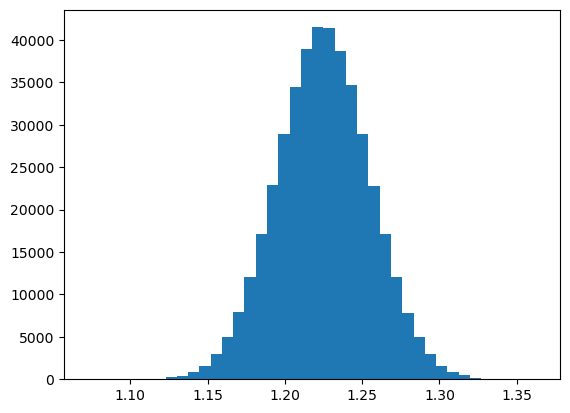

In [51]:
plt.hist(RhoRand,40)